# Games with the transverse field Ising model and entanglement entropy

## Install
Import Cytnx, see https://cytnx-dev.github.io/Cytnx/
and
https://github.com/Cytnx-dev/Cytnx/issues/1189

```console
$python -m pip install -U --pre --extra-index-url https://pypi.anaconda.org/cytnx-nightly-wheels/simple
cytnx-cuda
```
or
```console
pixi add --pypi cytnx-cuda --index https://pypi.anaconda.org/cytnx-nightly-wheels/simple
```

In [ ]:
# The following 2 lines are only needed if you installed Cytnx from source
# import sys
# sys.path.insert(0,'/home/manuel/Cytnx_lib') # change to your installation path

import cytnx
print(cytnx.__version__)

1.1.1


## Hamiltonian
Define parameters of transverse field Ising model
$$
H = J \sum_{k=0}^{N-2} \sigma_k^x \sigma_{k+1}^x + \beta \sum_{k=0}^{N-1} \sigma_k^z
$$

In [83]:
J = 1
beta = -0.3
# numerical costs here are exponential! N=8 should be fine, N=10 already pushes memory requirements to the limit
N = 8

Define the Pauli matrices and the identity:
$$
\sigma^x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad
\sigma^y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad
\sigma^z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}, \quad
\mathbb{1} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}
$$

In [84]:
# Pauli matrices are predefined in cytnx.physics
sx = cytnx.physics.pauli("x").real()
sy = cytnx.physics.pauli("y")
sz = cytnx.physics.pauli("z").real()
# identity matrix
I = cytnx.eye(2)

# print(sx)
# print(sy)
# print(sz)
# print(I)

Define the B tensors for the transverse field Ising model. $B$ is a $3 \times 3$ matrix whose entries are $2 \times 2$ operators:
$$
B = \begin{pmatrix}
\mathbb{1} & J \sigma^x & \beta \sigma^z \\
0 & 0 & \sigma^x \\
0 & 0 & \mathbb{1}
\end{pmatrix}
$$
We store it as a rank-4 `UniTensor` with labeled, directed indices:
* `l` (row) and `r` (column) are the virtual MPO indices,
* `s` is the physical index that connects to the state $|\psi\rangle$ when we apply $H|\psi\rangle$; it is an outgoing bond (`BD_BRA`),
* `s'` is the physical index that connects to the bra $\langle\psi|$; it is an incoming bond (`BD_KET`).

Directed bonds can only be contracted if an outgoing bond meets an incoming bond, which protects us from connecting the wrong indices.

In [85]:
B_data = cytnx.zeros([3, 3, 2, 2])
B_data[0, 0, :, :] = I
B_data[0, 1, :, :] = J * sx
B_data[0, 2, :, :] = beta * sz
B_data[1, 2, :, :] = sx
B_data[2, 2, :, :] = I

# print the matrix
Bnew = B_data.permute([0,2,1,3])
Bnew.reshape_(6,6)
print(Bnew)


# directed bonds: BD_KET = incoming, BD_BRA = outgoing
bond_l = cytnx.Bond(3, cytnx.BD_KET)
bond_r = cytnx.Bond(3, cytnx.BD_BRA)
bond_sp = cytnx.Bond(2, cytnx.BD_KET)  # s'
bond_s = cytnx.Bond(2, cytnx.BD_BRA)   # s

B = cytnx.UniTensor([bond_l, bond_r, bond_sp, bond_s], labels=["l", "r", "s'", "s"], rowrank=2, name="B")
B.put_block(B_data)

B.print_diagram()


Total elem: 36
type  : Double (Float64)
cytnx device: CPU
Shape : (6,6)
[[1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 -3.00000e-01 -0.00000e+00 ]
 [0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 -0.00000e+00 3.00000e-01 ]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 ]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 ]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 ]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 ]]



-----------------------
tensor Name : B
tensor Rank : 4
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : False
      row           col 
         -----------    
         |         |    
   l  -->| 3     2 |<--* s'
         |         |    
   r *<--| 3     2 |-->  s
         |         |    
         -----------    


Create one tensor per site. The boundary tensors are obtained by multiplying with boundary vectors:
$$
B_0 = \begin{pmatrix} 1 & 0 & 0 \end{pmatrix} B, \qquad
B_{N-1} = B \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}, \qquad
B_k = B \quad \text{for } 0 < k < N-1
$$
Each site tensor gets its own labels: the virtual index `v{k}` connects site $k-1$ with site $k$, and `s_{k}`, `s'_{k}` are the physical indices of site $k$. `Contract` sums over all indices with the same label. The boundary vectors need the opposite direction of the bond they are contracted with.

In [86]:
# boundary vectors
left = cytnx.UniTensor([cytnx.Bond(3, cytnx.BD_BRA)], labels=["v0"], rowrank=0, name="left")
left.at([0]).value = 1
right = cytnx.UniTensor([cytnx.Bond(3, cytnx.BD_KET)], labels=[f"v{N}"], rowrank=1, name="right")
right.at([2]).value = 1

# one copy of B per site, with site-dependent labels
MPO = [B.relabel([f"v{k}", f"v{k+1}", f"s'_{k}", f"s_{k}"]).set_name_(f"B{k}") for k in range(N)]

# B_0 = (1 0 0) B and B_{N-1} = B (0 0 1)^T
MPO[0] = cytnx.Contract(left, MPO[0]).set_name_("B0")
MPO[-1] = cytnx.Contract(MPO[-1], right).set_name_(f"B{N-1}")

# Show first and last tensor
# MPO[0].print_diagram()
# print(MPO[0])
# MPO[-1].print_diagram()
# print(MPO[-1])

Create the Hamiltonian: it is the product of all B tensors, where the virtual MPO indices are contracted:
$$
H = B_0 B_1 \cdots B_{N-1}
$$

In [87]:
H = MPO[0]
for k in range(1, N):
    H = cytnx.Contract(H, MPO[k])  # contracts the shared index v{k}
H.set_name_("H");

# permute indices to have all s' on the left and all s on the right
row_labels = [f"s'_{k}" for k in range(N)]
col_labels = [f"s_{k}" for k in range(N)]
H = H.permute(row_labels + col_labels, rowrank=N)
H.print_diagram()
print(H)

-----------------------
tensor Name : H
tensor Rank : 16
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : True
         row           col 
            -----------    
            |         |    
   s'_0  -->| 2     2 |-->  s_0
            |         |    
   s'_1  -->| 2     2 |-->  s_1
            |         |    
   s'_2  -->| 2     2 |-->  s_2
            |         |    
   s'_3  -->| 2     2 |-->  s_3
            |         |    
   s'_4  -->| 2     2 |-->  s_4
            |         |    
   s'_5  -->| 2     2 |-->  s_5
            |         |    
   s'_6  -->| 2     2 |-->  s_6
            |         |    
   s'_7  -->| 2     2 |-->  s_7
            |         |    
            -----------    
-------- start of print ---------
Tensor name: H
Tensor type: Dense
braket_form : True
is_diag    : False
contiguous : False

Total elem: 65536
type  : Double (Float64)
cytnx device: CPU
Shape : (2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2)
[[[[[[[[[[[[[[[[-2.40000e+00 0.

Finally, we combine the $N$ `s'` indices into one row index `s'` and the $N$ `s` indices into one column index `s`. This reshapes $H$ into a $2^N \times 2^N$ matrix:

In [88]:
Hmat = H.combineBond(row_labels)
Hmat.combineBond_(col_labels)
Hmat.relabel_(["s'", "s"]).set_rowrank_(1)

Hmat.print_diagram()
print(Hmat)

-----------------------
tensor Name : H
tensor Rank : 2
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : True
       row               col 
          ---------------    
          |             |    
   s'  -->| 256     256 |-->  s
          |             |    
          ---------------    
-------- start of print ---------
Tensor name: H
Tensor type: Dense
braket_form : True
is_diag    : False
contiguous : True

Total elem: 65536
type  : Double (Float64)
cytnx device: CPU
Shape : (256,256)
[[-2.40000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e

## Ground state
### Using Eigh
Find the spectrum: diagonalize $H$ with `Eigh` (eigenvalue decomposition for Hermitian matrices),
$$
H = V \, \mathrm{diag}(E_0, E_1, \dots) \, V^\dagger
$$
`Eigh` can be applied directly to the rank-$2N$ tensor `H`: the first `rowrank` indices ($s'_k$) are interpreted as the row index and the remaining ones ($s_k$) as the column index of a matrix. The eigenvalues are sorted in ascending order, so the first one is the ground state energy.

In [89]:
# Eigh gives all eigenvalues and eigenvectors for a Hermitean matrix
[eigvals, V] = cytnx.linalg.Eigh(H)
print(eigvals)

-------- start of print ---------
Tensor name: 
Tensor type: Dense
is_diag    : True
contiguous : True

Total elem: 256
type  : Double (Float64)
cytnx device: CPU
Shape : (256)
[-7.22662e+00 -7.22650e+00 -5.75623e+00 -5.75611e+00 -5.57709e+00 -5.57697e+00 -5.34871e+00 -5.34859e+00 -5.11795e+00 -5.11783e+00 -4.91486e+00 -4.91474e+00 -4.75832e+00 -4.75820e+00 -4.66007e+00 -4.65995e+00 -4.10670e+00 -4.10658e+00 -3.87832e+00 -3.87820e+00 -3.69918e+00 -3.69906e+00 -3.64756e+00 -3.64744e+00 -3.46842e+00 -3.46830e+00 -3.44446e+00 -3.44434e+00 -3.28792e+00 -3.28780e+00 -3.26533e+00 -3.26521e+00 -3.24004e+00 -3.23992e+00 -3.18967e+00 -3.18955e+00 -3.10879e+00 -3.10867e+00 -3.03695e+00 -3.03683e+00 -3.01054e+00 -3.01042e+00 -2.88041e+00 -2.88029e+00 -2.80619e+00 -2.80607e+00 -2.78216e+00 -2.78204e+00 -2.64965e+00 -2.64953e+00 -2.55140e+00 -2.55128e+00 -2.44655e+00 -2.44643e+00 -2.34830e+00 -2.34818e+00 -2.22879e+00 -2.22867e+00 -2.19176e+00 -2.19164e+00 -1.99803e+00 -1.99791e+00 -1.79493e+00 -1.

### Using Arnoldi
The full diagonalization costs $\mathcal{O}(2^{3N})$ and gives all eigenvalues, but we only need the ground state. Iterative methods like Arnoldi find a few extremal eigenvalues and only need the action $|\psi\rangle \mapsto H|\psi\rangle$ of the operator on a state, not the matrix itself.

In Cytnx, this action is defined by a class that inherits from `LinOp` and implements `matvec`. Here, $|\psi\rangle$ is a rank-$N$ `UniTensor` with incoming bonds (`BD_KET`) labeled `s_k`, such that it can be contracted with the indices `s_k` of $H$. The result carries the labels `s'_k`; we relabel them to `s_k` so that the output has the same form as the input.

In [90]:
class HamiltonianOp(cytnx.LinOp):
    def __init__(self, H, labels):
        # "mv": the operator is defined by matvec; 2**N is the dimension of the vector space
        cytnx.LinOp.__init__(self, "mv", 2 ** len(labels))
        self.H = H
        self.labels = labels

    def matvec(self, psi):
        Hpsi = cytnx.Contract(self.H, psi)  # contracts all indices s_k
        return Hpsi.relabel(self.labels)    # s'_k -> s_k

H_op = HamiltonianOp(H, col_labels)

Arnoldi needs a starting vector; we use a random state. `which="SR"` asks for the eigenvalue with the smallest real part. Arnoldi works for general (also non-Hermitian) operators, so the results are returned as complex numbers.

In [91]:
psi_init = cytnx.UniTensor([cytnx.Bond(2, cytnx.BD_KET) for k in range(N)], labels=col_labels, rowrank=N, name="psi_init")
cytnx.random.uniform_(psi_init, -1, 1, seed=0)

energies, psi0 = cytnx.linalg.Arnoldi(H_op, psi_init, which="SR", k=1, CvgCrit=1e-12)
psi0.set_name_("psi0")

E0 = energies.get_block()[0].item().real
print("lowest eigenvalue from Arnoldi: E0 =", E0)
print("difference to Eigh:", E0 - eigvals.get_block()[0].item())

psi0.print_diagram()
print(psi0)

lowest eigenvalue from Arnoldi: E0 = -7.226620000024457
difference to Eigh: 7.993605777301127e-15
-----------------------
tensor Name : psi0
tensor Rank : 8
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : True
        row          col 
           ----------    
           |        |    
   s_0  -->| 2      |        
           |        |    
   s_1  -->| 2      |        
           |        |    
   s_2  -->| 2      |        
           |        |    
   s_3  -->| 2      |        
           |        |    
   s_4  -->| 2      |        
           |        |    
   s_5  -->| 2      |        
           |        |    
   s_6  -->| 2      |        
           |        |    
   s_7  -->| 2      |        
           |        |    
           ----------    
-------- start of print ---------
Tensor name: psi0
Tensor type: Dense
braket_form : True
is_diag    : False
contiguous : True

Total elem: 256
type  : Complex Double (Complex Float64)
cytnx device: C

Check the eigenvalue equation $H|\psi_0\rangle = E_0 |\psi_0\rangle$ and the normalization $\langle\psi_0|\psi_0\rangle = 1$:

In [92]:
Hpsi = H_op.matvec(psi0)

print("|H psi0 - E0 psi0| =", (Hpsi - E0 * psi0).norm())
print("|psi0| =", psi0.norm())

|H psi0 - E0 psi0| = 4.237948868972785e-12
|psi0| = 1.0000000000000002


## Entanglement spectrum
We cut the chain in the middle: the first $\lceil N/2 \rceil$ sites form the left part, the remaining sites the right part. Setting `rowrank` to the cut position tells `Svd` which indices belong to the left (rows) and to the right (columns):
$$
|\psi_0\rangle = \sum_j \lambda_j \, |u_j\rangle_\text{left} \otimes |v_j\rangle_\text{right}
\qquad \Leftrightarrow \qquad \psi_0 = U S V^\dagger
$$
The singular values $\lambda_j$ are the Schmidt coefficients of the state.

In [93]:
cut = (N + 1) // 2  # N/2, rounded up

psi0.set_rowrank_(cut)
[S, U, V] = cytnx.linalg.Svd(psi0)
print(S)

-------- start of print ---------
Tensor name: 
Tensor type: Dense
braket_form : True
is_diag    : True
contiguous : True

Total elem: 16
type  : Double (Float64)
cytnx device: CPU
Shape : (16)
[7.12732e-01 7.01412e-01 4.18576e-03 4.11928e-03 2.27942e-05 2.24322e-05 1.33867e-07 1.31741e-07 6.54817e-08 6.44417e-08 3.84607e-10 3.78434e-10 2.07427e-12 2.06328e-12 9.57892e-14 2.68958e-15 ]






singular values: [0.7127316650473814, 0.7014122065587142, 0.004185761841631887, 0.004119284428378678, 2.2794248663219714e-05, 2.2432235023295965e-05, 1.3386706222755165e-07, 1.3174100663169376e-07, 6.548165977093742e-08, 6.444169156781872e-08, 3.846071892435719e-10, 3.784338091258659e-10, 2.0742678127196933e-12, 2.063279143095489e-12, 9.578917580471053e-14, 2.689583269048896e-15]


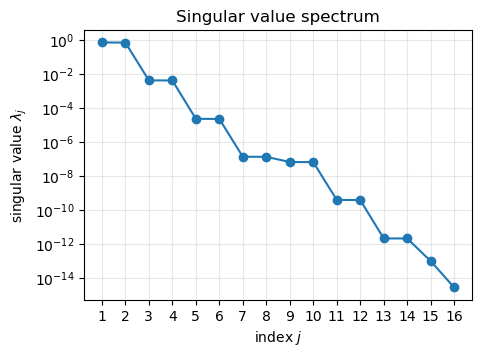

In [94]:
import matplotlib.pyplot as plt

num_svals = S.shape()[0]
svals = [S.get_block()[j].item() for j in range(num_svals)]
print("singular values:", svals)

plt.figure(figsize=(5, 3.5))
plt.semilogy(range(1, num_svals + 1), svals, "o-")
plt.xticks(range(1, num_svals + 1))
plt.xlabel("index $j$")
plt.ylabel(r"singular value $\lambda_j$")
plt.title("Singular value spectrum")
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Entanglement entropy
The squared singular values $p_j = \lambda_j^2$ are probabilities (they sum to 1 for a normalized state). The entanglement entropy between the left and the right part is
$$
S_E = - \sum_j \lambda_j^2 \log_2 \lambda_j^2
$$

In [95]:
import math

def entanglement_entropy(svals):
    probs = [s**2 for s in svals if s > 1e-16]  # skip zeros: 0 * ln(0) = 0
    return -sum(p * math.log2(p) for p in probs)

print("entanglement entropy:", entanglement_entropy(svals))
print("maximum possible value ln(%d) = %f" % (num_svals, math.log2(num_svals)))

entanglement entropy: 1.0003761825406483
maximum possible value ln(16) = 4.000000


### Fidelity and energy
The fidelity measures how close two states are. It is 1 for identical states and 0 for orthogonal states:
$$
F(\psi, \phi) = \frac{|\langle\psi|\phi\rangle|}{\sqrt{\langle\psi|\psi\rangle \langle\phi|\phi\rangle}}, \qquad
E(\psi) = \frac{\langle\psi|H|\psi\rangle}{\langle\psi|\psi\rangle}
$$
`Dagger` turns the ket $|\psi\rangle$ into the bra $\langle\psi|$: it takes the complex conjugate and flips the bond directions, so the bra can be contracted with a ket.

In [96]:
def overlap(psi, phi):
    # <psi|phi>
    return cytnx.Contract(psi.Dagger(), phi).item()

def fidelity(psi, phi):
    return abs(overlap(psi, phi)) / math.sqrt((overlap(psi, psi) * overlap(phi, phi)).real)

def energy(psi):
    return (overlap(psi, H_op.matvec(psi)) / overlap(psi, psi)).real

print("fidelity of psi0 with itself:", fidelity(psi0, psi0))
print("energy of psi0:", energy(psi0))

fidelity of psi0 with itself: 1.0


energy of psi0: -7.2266200000244565


### Truncation
Now we approximate the ground state: we keep only the largest singular values, set the others to zero, and rebuild the state $\psi = U S V^\dagger$. We start with all singular values and remove the smallest one in each step, until only one is left.

In [97]:
kept_list = []
energy_list = []
fidelity_list = []

for kept in range(num_svals, 0, -1):
    # set all but the largest `kept` singular values to zero
    s = S.get_block()
    for j in range(kept, num_svals):
        s[j] = 0
    S_trunc = S.clone()
    S_trunc.put_block(s)

    # rebuild the state: psi = U S V^dagger
    psi = cytnx.Contract(cytnx.Contract(U, S_trunc), V)

    kept_list.append(kept)
    energy_list.append(energy(psi))
    fidelity_list.append(fidelity(psi0, psi))
    print("kept = %d: energy error = %.3e, infidelity = %.3e" % (kept, abs(energy_list[-1] - E0), 1 - fidelity_list[-1]))

kept = 16: energy error = 1.776e-15, infidelity = 0.000e+00
kept = 15: energy error = 2.665e-15, infidelity = 2.220e-16
kept = 14: energy error = 2.665e-15, infidelity = 0.000e+00
kept = 13: energy error = 4.441e-15, infidelity = 0.000e+00
kept = 12: energy error = 5.329e-15, infidelity = 2.220e-16
kept = 11: energy error = 2.665e-15, infidelity = 2.220e-16
kept = 10: energy error = 4.441e-15, infidelity = 4.441e-16
kept = 9: energy error = 2.132e-14, infidelity = 2.109e-15
kept = 8: energy error = 3.997e-14, infidelity = 4.219e-15
kept = 7: energy error = 1.936e-13, infidelity = 1.310e-14
kept = 6: energy error = 3.135e-13, infidelity = 2.198e-14
kept = 5: energy error = 2.529e-09, infidelity = 2.516e-10
kept = 4: energy error = 4.125e-09, infidelity = 5.114e-10
kept = 3: energy error = 8.329e-05, infidelity = 8.485e-06
kept = 2: energy error = 1.350e-04, infidelity = 1.725e-05
kept = 1: energy error = 9.615e-01, infidelity = 2.873e-01


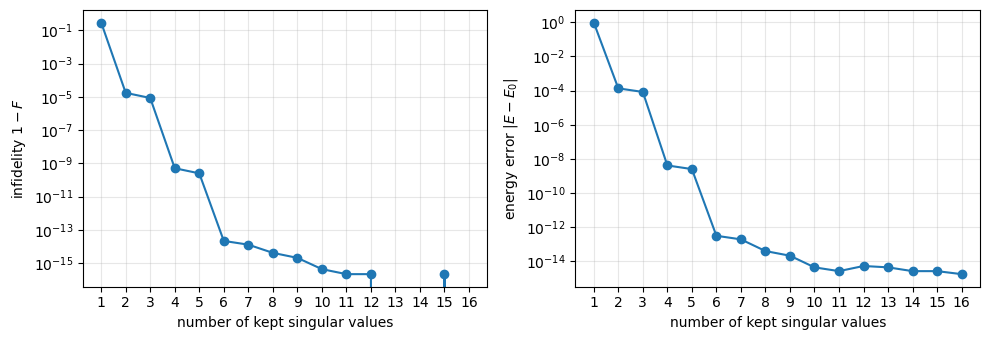

In [98]:
energy_error_list = [abs(E - E0) for E in energy_list]
infidelity_list = [1 - F for F in fidelity_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.semilogy(kept_list, infidelity_list, "o-")
ax1.set_xticks(kept_list)
ax1.set_xlabel("number of kept singular values")
ax1.set_ylabel("infidelity $1 - F$")
ax1.grid(True, which="both", alpha=0.3)

ax2.semilogy(kept_list, energy_error_list, "o-")
ax2.set_xticks(kept_list)
ax2.set_xlabel("number of kept singular values")
ax2.set_ylabel("energy error $|E - E_0|$")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Matrix product state
Now we split the state site by site. An SVD with the first site on the left gives $\psi_0 = U_0 \, (S V^\dagger)$. $U_0$ is the MPS tensor of site 0; it has the physical index `s_0` and a new bond index `b0`. The remainder $S V^\dagger$ is again decomposed by an SVD, this time with `b0` and `s_1` on the left, which gives $U_1$ and a new remainder. Repeating this for all sites, we obtain
$$
\psi_0 = U_0 \, U_1 \cdots U_{N-2} \, R
$$
where the last tensor $R$ contains the remaining $S V^\dagger$.

In each step, we keep at most $D$ singular values (`Svd_truncate`). $D$ is called the bond dimension. The bond between sites $k-1$ and $k$ has at most $\min(2^k, 2^{N-k})$ singular values, so $D_\text{max} = 2^{\lfloor N/2 \rfloor}$ reproduces the state exactly.

In [99]:
def to_mps(psi, D):
    """Split psi into MPS tensors by successive SVDs, keeping at most D singular values per bond."""
    tensors = []
    rest = psi.clone()
    for k in range(N - 1):
        # left: (bond, s_k); the first site has no left bond
        rest.set_rowrank_(1 if k == 0 else 2)
        [S, U, V] = cytnx.linalg.Svd_truncate(rest, keepdim=D)
        U.relabel_("_aux_L", f"b{k}").set_name_(f"A{k}")
        S.relabel_("_aux_L", f"b{k}")
        tensors.append(U)
        rest = cytnx.Contract(S, V)  # remainder for the next step
    tensors.append(rest.set_name_(f"A{N-1}"))
    return tensors

def to_state(tensors):
    """Contract all MPS tensors into a rank-N state. This is not efficient!"""
    psi = tensors[0]
    for T in tensors[1:]:
        psi = cytnx.Contract(psi, T)
    return psi.permute(col_labels, rowrank=N)

mps = to_mps(psi0, D=3)
for T in mps:
    T.print_diagram()

-----------------------
tensor Name : A0
tensor Rank : 2
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : True
        row           col 
           -----------    
           |         |    
   s_0  -->| 2     2 |-->  b0
           |         |    
           -----------    
-----------------------
tensor Name : A1
tensor Rank : 3
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : True
        row           col 
           -----------    
           |         |    
   b0   -->| 2     3 |-->  b1
           |         |    
   s_1  -->| 2       |        
           |         |    
           -----------    
-----------------------
tensor Name : A2
tensor Rank : 3
block_form  : False
is_diag     : False
on device   : cytnx device: CPU
braket_form : True
        row           col 
           -----------    
           |         |    
   b1   -->| 3     3 |-->  b2
           |         |    
   s_2  -->| 2       |        

We repeat this for all bond dimensions from 1 to $D_\text{max}$ and compare the resulting state with the ground state:

In [100]:
D_max = 2 ** (N // 2)
D_list = list(range(1, D_max + 1))
mps_energy_error = []
mps_infidelity = []

for D in D_list:
    psi = to_state(to_mps(psi0, D))
    mps_energy_error.append(abs(energy(psi) - E0))
    mps_infidelity.append(1 - fidelity(psi0, psi))
    print("D = %2d: energy error = %.3e, infidelity = %.3e" % (D, mps_energy_error[-1], mps_infidelity[-1]))

D =  1: energy error = 4.827e+00, infidelity = 8.126e-01
D =  2: energy error = 6.091e-04, infidelity = 7.630e-05
D =  3: energy error = 3.670e-04, infidelity = 3.666e-05
D =  4: energy error = 1.004e-08, infidelity = 1.218e-09
D =  5: energy error = 6.114e-09, infidelity = 5.975e-10
D =  6: energy error = 7.105e-13, infidelity = 4.630e-14
D =  7: energy error = 4.068e-13, infidelity = 2.487e-14
D =  8: energy error = 3.730e-14, infidelity = 4.219e-15
D =  9: energy error = 2.132e-14, infidelity = 2.331e-15
D = 10: energy error = 5.329e-15, infidelity = 4.441e-16
D = 11: energy error = 3.553e-15, infidelity = 2.220e-16
D = 12: energy error = 7.105e-15, infidelity = 0.000e+00
D = 13: energy error = 1.776e-15, infidelity = 2.220e-16
D = 14: energy error = 4.441e-15, infidelity = -2.220e-16
D = 15: energy error = 3.553e-15, infidelity = 0.000e+00
D = 16: energy error = 0.000e+00, infidelity = 4.441e-16


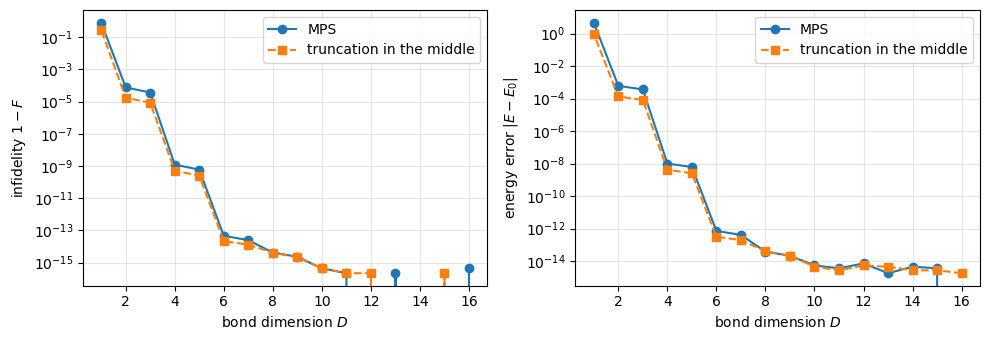

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.semilogy(D_list, mps_infidelity, "o-", label="MPS")
ax1.semilogy(kept_list, infidelity_list, "s--", label="truncation in the middle")
ax1.set_xlabel("bond dimension $D$")
ax1.set_ylabel("infidelity $1 - F$")
ax1.legend()
ax1.grid(True, which="both", alpha=0.3)

ax2.semilogy(D_list, mps_energy_error, "o-", label="MPS")
ax2.semilogy(kept_list, energy_error_list, "s--", label="truncation in the middle")
ax2.set_xlabel("bond dimension $D$")
ax2.set_ylabel("energy error $|E - E_0|$")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()